# Malware Classifier From Maling Image Dataset Using Custom Model 

In [2]:
import tensorflow

In [3]:
print(tensorflow.__version__)

2.3.1


In [1]:
from keras.preprocessing.image import ImageDataGenerator
dataset_path = "/home/dipak/MalwareClassification/malimg_paper_dataset_imgs/"
augs_gen = ImageDataGenerator().flow_from_directory(directory=dataset_path, target_size=(64,64),
                                                    batch_size=10000)

Found 9339 images belonging to 25 classes.


In [2]:
images, labels = next(augs_gen)

<BarContainer object of 25 artists>

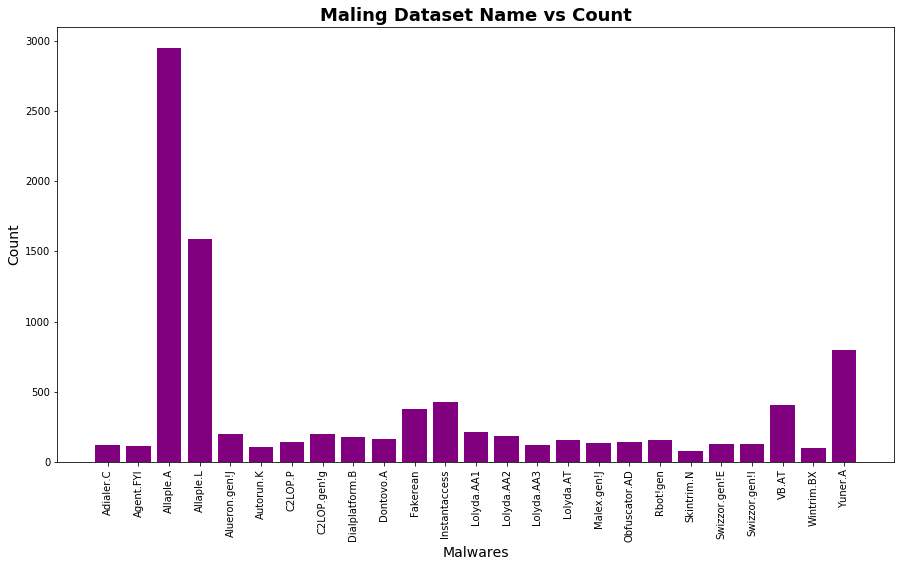

In [3]:
import matplotlib.pyplot as plt
classes = augs_gen.class_indices.keys()
perc = (sum(labels))
plt.figure(figsize=(15,8))
plt.xticks(rotation='vertical')
plt.title("Maling Dataset Name vs Count", fontweight='bold',fontsize=18)
plt.xlabel("Malwares",fontsize=14)
plt.ylabel("Count",fontsize=14)
plt.bar(classes,perc, color=['purple'])

## Train Test Split

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images/255.,labels,
                                                    test_size=0.2)

# Implementing CNN

In [5]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Flatten,Dropout
from tensorflow.keras import regularizers

**Creating Model Architecture**

In [6]:
model = Sequential()
model.add(Conv2D(32,(3,3),padding='same',input_shape=(64,64,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(32,(3,3),padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(32,(3,3),padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(units=512,activation='relu'))
model.add(Dense(units=128,activation='relu'))
model.add(Dense(units=64,activation='relu'))
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=25,activation='sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 64, 64, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 32, 32, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 32, 32, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 16, 16, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 16, 16, 32)        9248      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 8, 8, 32)          0         
_________________________________________________________________
flatten (Flatten)            (None, 2048)              0

### Early Stopping & Checkpoint

In [7]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint

earlystop = EarlyStopping(monitor='val_loss',
                         patience=6,
                         min_delta = 0.00001,
                         verbose = 1,
                         restore_best_weights = True)

checkpoint = ModelCheckpoint('MalingModel.h5',
                             monitor='val_loss',
                            save_best_only=True,
                            mode='auto',
                            verbose=1)

reduceLR = ReduceLROnPlateau(monitor='val_loss',
                            patience=6,
                            min_delta=0.00001,
                            verbose=1,
                            factor=0.01)

callback = [earlystop,checkpoint,reduceLR]

In [8]:
from tensorflow.keras.optimizers import SGD,RMSprop
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [9]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),epochs=25,callbacks=callback)

Epoch 1/25
234/234 [==============================] - ETA: 0s - loss: 1.6977 - accuracy: 0.4267
Epoch 00001: val_loss improved from inf to 0.70640, saving model to MalingModel.h5
234/234 [==============================] - 27s 115ms/step - loss: 1.6977 - accuracy: 0.4267 - val_loss: 0.7064 - val_accuracy: 0.5744
Epoch 2/25
234/234 [==============================] - ETA: 0s - loss: 0.4821 - accuracy: 0.7988
Epoch 00002: val_loss improved from 0.70640 to 0.50991, saving model to MalingModel.h5
234/234 [==============================] - 27s 113ms/step - loss: 0.4821 - accuracy: 0.7988 - val_loss: 0.5099 - val_accuracy: 0.7971
Epoch 3/25
234/234 [==============================] - ETA: 0s - loss: 0.2228 - accuracy: 0.9291
Epoch 00003: val_loss improved from 0.50991 to 0.16096, saving model to MalingModel.h5
234/234 [==============================] - 26s 113ms/step - loss: 0.2228 - accuracy: 0.9291 - val_loss: 0.1610 - val_accuracy: 0.9497
Epoch 4/25
234/234 [==============================] -

**Evaluate the model Accuracy**

In [10]:
print("Evaluation on Test data")
results = model.evaluate(X_test, y_test)
print("Test loss, Test acc:", results)

Evaluation on Test data
59/59 [==============================] - 2s 31ms/step - loss: 0.0716 - accuracy: 0.9807
Test loss, Test acc: [0.0716213509440422, 0.980728030204773]


**Confusion Matrix**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix


y_pred = model.predict_classes(X_test, verbose=0)
y_test2 = np.argmax(y_test, axis=1)
reasult = confusion_matrix(y_test2, y_pred)
reasult

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).


array([[ 25,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  23,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0, 613,   0,   0,   0,   0,   0,   0,   0,   0,   2,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   1, 325,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,  39,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  23,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  14,   3,   0,   0,   0,   0,   0,
          0,   0,   1,   0,   0,   0,   0,   0,   2,   0,   0,   0],
      

Text(0.5, 42.0, 'Predicted label')

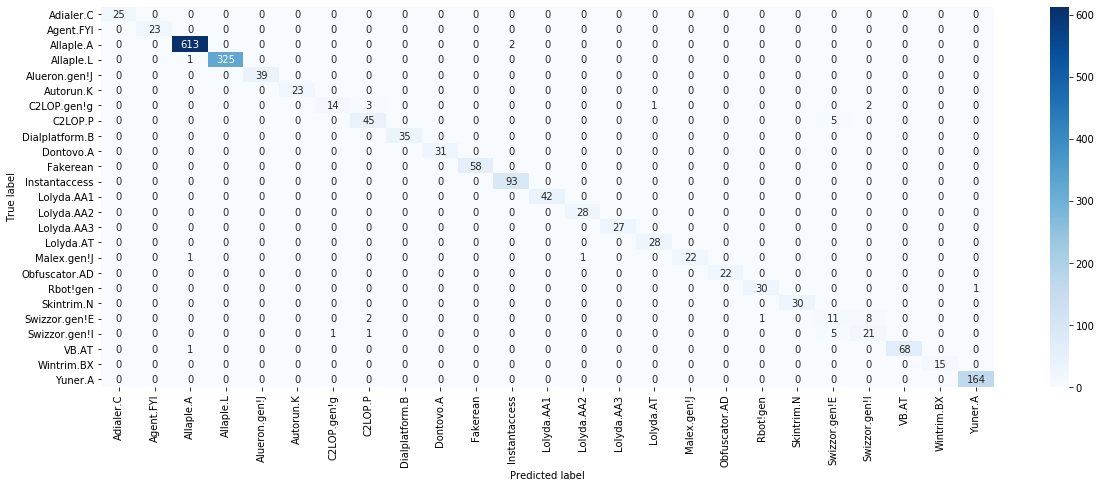

In [12]:
import seaborn as sns
x_axis_labels = ['Adialer.C','Agent.FYI','Allaple.A','Allaple.L','Alueron.gen!J','Autorun.K',
              'C2LOP.gen!g','C2LOP.P','Dialplatform.B','Dontovo.A','Fakerean','Instantaccess',
              'Lolyda.AA1','Lolyda.AA2','Lolyda.AA3','Lolyda.AT','Malex.gen!J','Obfuscator.AD','Rbot!gen',
              'Skintrim.N','Swizzor.gen!E','Swizzor.gen!I','VB.AT','Wintrim.BX','Yuner.A']

y_axis_labels = ['Adialer.C','Agent.FYI','Allaple.A','Allaple.L','Alueron.gen!J','Autorun.K',
              'C2LOP.gen!g','C2LOP.P','Dialplatform.B','Dontovo.A','Fakerean','Instantaccess',
              'Lolyda.AA1','Lolyda.AA2','Lolyda.AA3','Lolyda.AT','Malex.gen!J','Obfuscator.AD','Rbot!gen',
              'Skintrim.N','Swizzor.gen!E','Swizzor.gen!I','VB.AT','Wintrim.BX','Yuner.A']

fig = plt.figure(figsize=(20,7))
heatmap = sns.heatmap(reasult, annot=True, fmt="d",
                      xticklabels=x_axis_labels, 
                      yticklabels=y_axis_labels,cmap='Blues')
plt.ylabel('True label')
plt.xlabel('Predicted label')

## Plot the Graph

**Loss and Accuracy Curves**

Text(0.5, 1.0, 'Accuracy Curves')

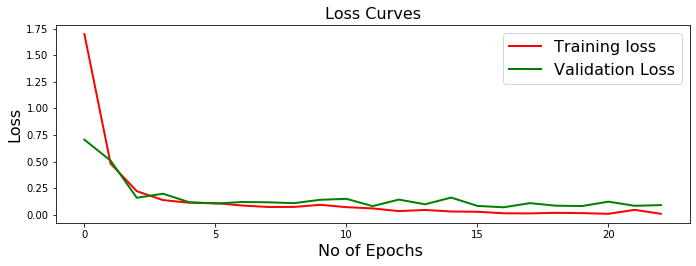

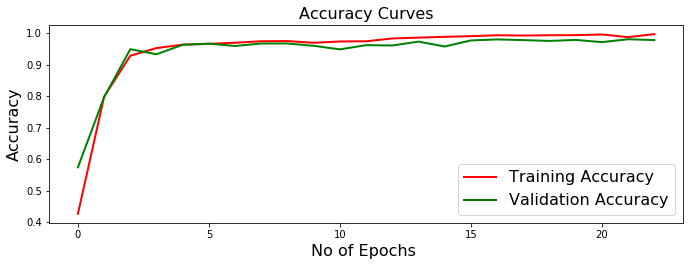

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=[25,8])
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'],'r',linewidth=2.0)
plt.plot(history.history['val_loss'],'g',linewidth=2.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=16)
plt.xlabel('No of Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
  
plt.figure(figsize=[25,8])
plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'],'r',linewidth=2.0)
plt.plot(history.history['val_accuracy'],'g',linewidth=2.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=16)
plt.xlabel('No of Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)


### -----------------------------------------------------------Testing on Real Image---------------------------------------------------------------

In [24]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
classifier = load_model('/home/dipak/MalwareClassification/MalingModel.h5')
test_image = image.load_img('/home/dipak/MalwareClassification/agent2.png',target_size = (64,64))
test_array = np.expand_dims(test_image,axis = 0)

result = classifier.predict(test_array)

if result[0][0] == 1:
    prediction = 'Agent'
    print(prediction)
elif result[0][1] == 1:
    prediction = 'B'
    print(prediction)
elif result[0][2] == 1:
    prediction = 'C'
    print(prediction)
elif result[0][3] == 1:
    prediction = 'D'
    print(prediction)
elif result[0][4] == 1:
    prediction = 'E'
    print(prediction)
elif result[0][5] == 1:
    prediction = 'F'
    print(prediction)
elif result[0][6] == 1:
    prediction = 'G'
    print(prediction)
elif result[0][7] == 1:
    prediction = 'H'
    print(prediction)
elif result[0][8] == 1:
    prediction = 'I'
    print(prediction)
elif result[0][9] == 1:
    prediction = 'J'
    print(prediction)
elif result[0][10] == 1:
    prediction = 'K'
    print(prediction)
elif result[0][11] == 1:
    prediction = 'L'
    print(prediction)
elif result[0][12] == 1:
    prediction = 'M'
    print(prediction)
elif result[0][13] == 1:
    prediction = 'N'
    print(prediction)
elif result[0][14] == 1:
    prediction = 'O'
    print(prediction)
elif result[0][15] == 1:
    prediction = 'P'
    print(prediction)
elif result[0][16] == 1:
    prediction = 'Q'
    print(prediction)
elif result[0][17] == 1:
    prediction = 'R'
    print(prediction)
elif result[0][18] == 1:
    prediction = 'S'
    print(prediction)
elif result[0][19] == 1:
    prediction = 'T'
    print(prediction)
elif result[0][20] == 1:
    prediction = 'U'
    print(prediction)
elif result[0][21] == 1:
    prediction = 'V'
    print(prediction)
elif result[0][22] == 1:
    prediction = 'W'
    print(prediction)
elif result[0][23] == 1:
    prediction = 'X'
    print(prediction)
elif result[0][24] == 1:
    prediction = 'Y'
    print(prediction)




******************************************************************************************